# T05 — Outlier and Suspicious-Value Analysis

**Objective:** identify, quantify, visualize, and cautiously classify unusual values in the unchanged `weatherAUS.csv` dataset.

**Boundary:** no row or value is removed, capped, transformed, imputed, or recoded. No feature engineering, splitting, modelling, or T06 work occurs here.

> **Statistical outlier is not the same as domain error.** An IQR flag means that a value is unusual relative to the sample distribution. A domain error requires evidence that a credible physical or measurement constraint was violated.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fdm_rainfall.data import load_weather_data
from fdm_rainfall.outliers import (
    ALLOWED_CLASSIFICATIONS,
    NUMERICAL_FEATURES,
    UNITS,
    cloud_nine_investigation,
    extreme_pattern_summary,
    extreme_weather_context,
    humidity_boundary_summary,
    iqr_outlier_summary,
    outlier_decision_summary,
    percentile_summary,
    proposal_consistency,
    rainfall_skewness_summary,
    suspicious_value_details,
)

DATASET_PATH = PROJECT_ROOT / "data/raw/weatherAUS.csv"
TABLE_DIR = PROJECT_ROOT / "reports/tables"
FIGURE_DIR = PROJECT_ROOT / "reports/figures/outliers"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
PRIMARY = "#4C78A8"
ACCENT = "#E45756"
CAUTION = "#F2CF5B"
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 140)

## Load the original data without modification

In [2]:
weather = load_weather_data(DATASET_PATH)
raw_shape = weather.shape
print(f"Loaded {raw_shape[0]:,} rows × {raw_shape[1]} columns.")
print("All following operations create summaries or figures; the raw frame is not reassigned or written.")

Loaded 145,460 rows × 23 columns.
All following operations create summaries or figures; the raw frame is not reassigned or written.


## 1. Percentiles, skewness, and IQR screening

,Feature,Unit,Non-missing count,Minimum,1st percentile,5th percentile,25th percentile,Median,75th percentile,95th percentile,99th percentile,Maximum,IQR,Skewness
0,MinTemp,°C,143975,-8.5,-1.9,1.8,7.6,12.0,16.9,23.0,25.8,33.9,9.3,0.021188
1,MaxTemp,°C,144199,-4.8,9.0,12.8,17.9,22.6,28.2,35.5,40.1,48.1,10.3,0.220839
2,Rainfall,mm,142199,0.0,0.0,0.0,0.0,0.0,0.8,13.0,37.4,371.0,0.8,9.836225
3,Evaporation,mm,82670,0.0,0.4,1.0,2.6,4.8,7.4,12.0,18.4,145.0,4.8,3.761286
4,Sunshine,hours,75625,0.0,0.0,0.3,4.8,8.4,10.6,12.8,13.4,14.5,5.8,-0.496480
5,WindGustSpeed,km/h,135197,6.0,15.0,20.0,31.0,39.0,48.0,65.0,81.0,135.0,17.0,0.874879
6,WindSpeed9am,km/h,143693,0.0,0.0,0.0,7.0,13.0,19.0,30.0,39.0,130.0,12.0,0.777630
7,WindSpeed3pm,km/h,142398,0.0,2.0,6.0,13.0,19.0,24.0,35.0,43.0,87.0,11.0,0.628215
8,Humidity9am,%,142806,0.0,18.0,34.0,57.0,70.0,83.0,98.0,100.0,100.0,26.0,-0.483969
9,Humidity3pm,%,140953,0.0,9.0,17.0,37.0,52.0,66.0,88.0,98.0,100.0,29.0,0.033614


,Feature,Non-missing count,Q1,Q3,IQR,Lower fence,Upper fence,Count below lower fence,Count above upper fence,Total IQR-flagged,Percentage IQR-flagged,Interpretation
0,MinTemp,143975,7.6,16.9,9.3,-6.35,30.85,46,8,54,0.0375,Statistical screening only; an IQR flag is not a domain error.
1,MaxTemp,144199,17.9,28.2,10.3,2.45,43.65,320,169,489,0.3391,Statistical screening only; an IQR flag is not a domain error.
2,Rainfall,142199,0.0,0.8,0.8,-1.20,2.00,0,25578,25578,17.9875,Statistical screening only; an IQR flag is not a domain error.
3,Evaporation,82670,2.6,7.4,4.8,-4.60,14.60,0,1995,1995,2.4132,Statistical screening only; an IQR flag is not a domain error.
4,Sunshine,75625,4.8,10.6,5.8,-3.90,19.30,0,0,0,0.0000,Statistical screening only; an IQR flag is not a domain error.
5,WindGustSpeed,135197,31.0,48.0,17.0,5.50,73.50,0,3092,3092,2.2870,Statistical screening only; an IQR flag is not a domain error.
6,WindSpeed9am,143693,7.0,19.0,12.0,-11.00,37.00,0,1817,1817,1.2645,Statistical screening only; an IQR flag is not a domain error.
7,WindSpeed3pm,142398,13.0,24.0,11.0,-3.50,40.50,0,2523,2523,1.7718,Statistical screening only; an IQR flag is not a domain error.
8,Humidity9am,142806,57.0,83.0,26.0,18.00,122.00,1425,0,1425,0.9979,Statistical screening only; an IQR flag is not a domain error.
9,Humidity3pm,140953,37.0,66.0,29.0,-6.50,109.50,0,0,0,0.0000,Statistical screening only; an IQR flag is not a domain error.


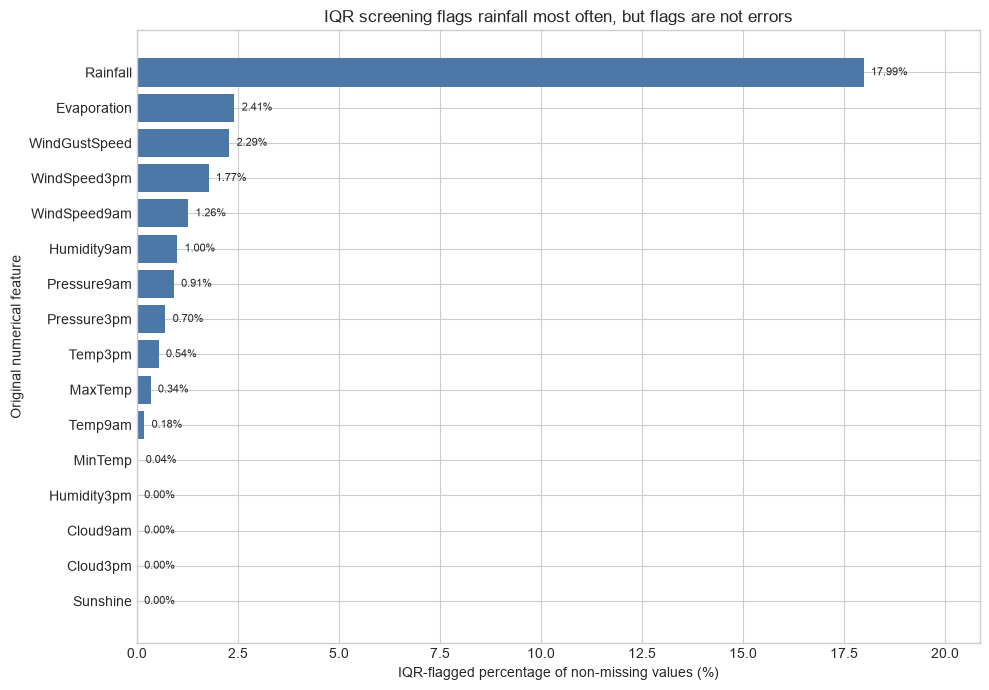

In [3]:
percentiles = percentile_summary(weather)
iqr_summary = iqr_outlier_summary(weather)
percentiles.to_csv(TABLE_DIR / "05_percentile_summary.csv", index=False)
iqr_summary.to_csv(TABLE_DIR / "05_outlier_summary.csv", index=False)
display(percentiles)
display(iqr_summary)

fig, ax = plt.subplots(figsize=(10, 7))
plot_iqr = iqr_summary.sort_values("Percentage IQR-flagged")
bars = ax.barh(plot_iqr["Feature"], plot_iqr["Percentage IQR-flagged"], color=PRIMARY)
ax.set_title("IQR screening flags rainfall most often, but flags are not errors")
ax.set_xlabel("IQR-flagged percentage of non-missing values (%)")
ax.set_ylabel("Original numerical feature")
for bar, value in zip(bars, plot_iqr["Percentage IQR-flagged"]):
    ax.text(value + 0.18, bar.get_y() + bar.get_height() / 2, f"{value:.2f}%", va="center", fontsize=8)
ax.set_xlim(0, plot_iqr["Percentage IQR-flagged"].max() * 1.16)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_iqr_flagged_percentages.png", dpi=180, bbox_inches="tight")
plt.show()

C:\Users\Jeewa's Lap\AppData\Local\Temp\ipykernel_15216\3700761624.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = ax.boxplot(values, vert=True, patch_artist=True, showfliers=True,
C:\Users\Jeewa's Lap\AppData\Local\Temp\ipykernel_15216\3700761624.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = ax.boxplot(values, vert=True, patch_artist=True, showfliers=True,
C:\Users\Jeewa's Lap\AppData\Local\Temp\ipykernel_15216\3700761624.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  box = ax.boxplot(values, vert=True, patch_artist=True, showfliers=True,
C:\Users\Jeewa's Lap\AppData\Local\Temp\ipykernel_15216\3700761624.py:4: MatplotlibDepre

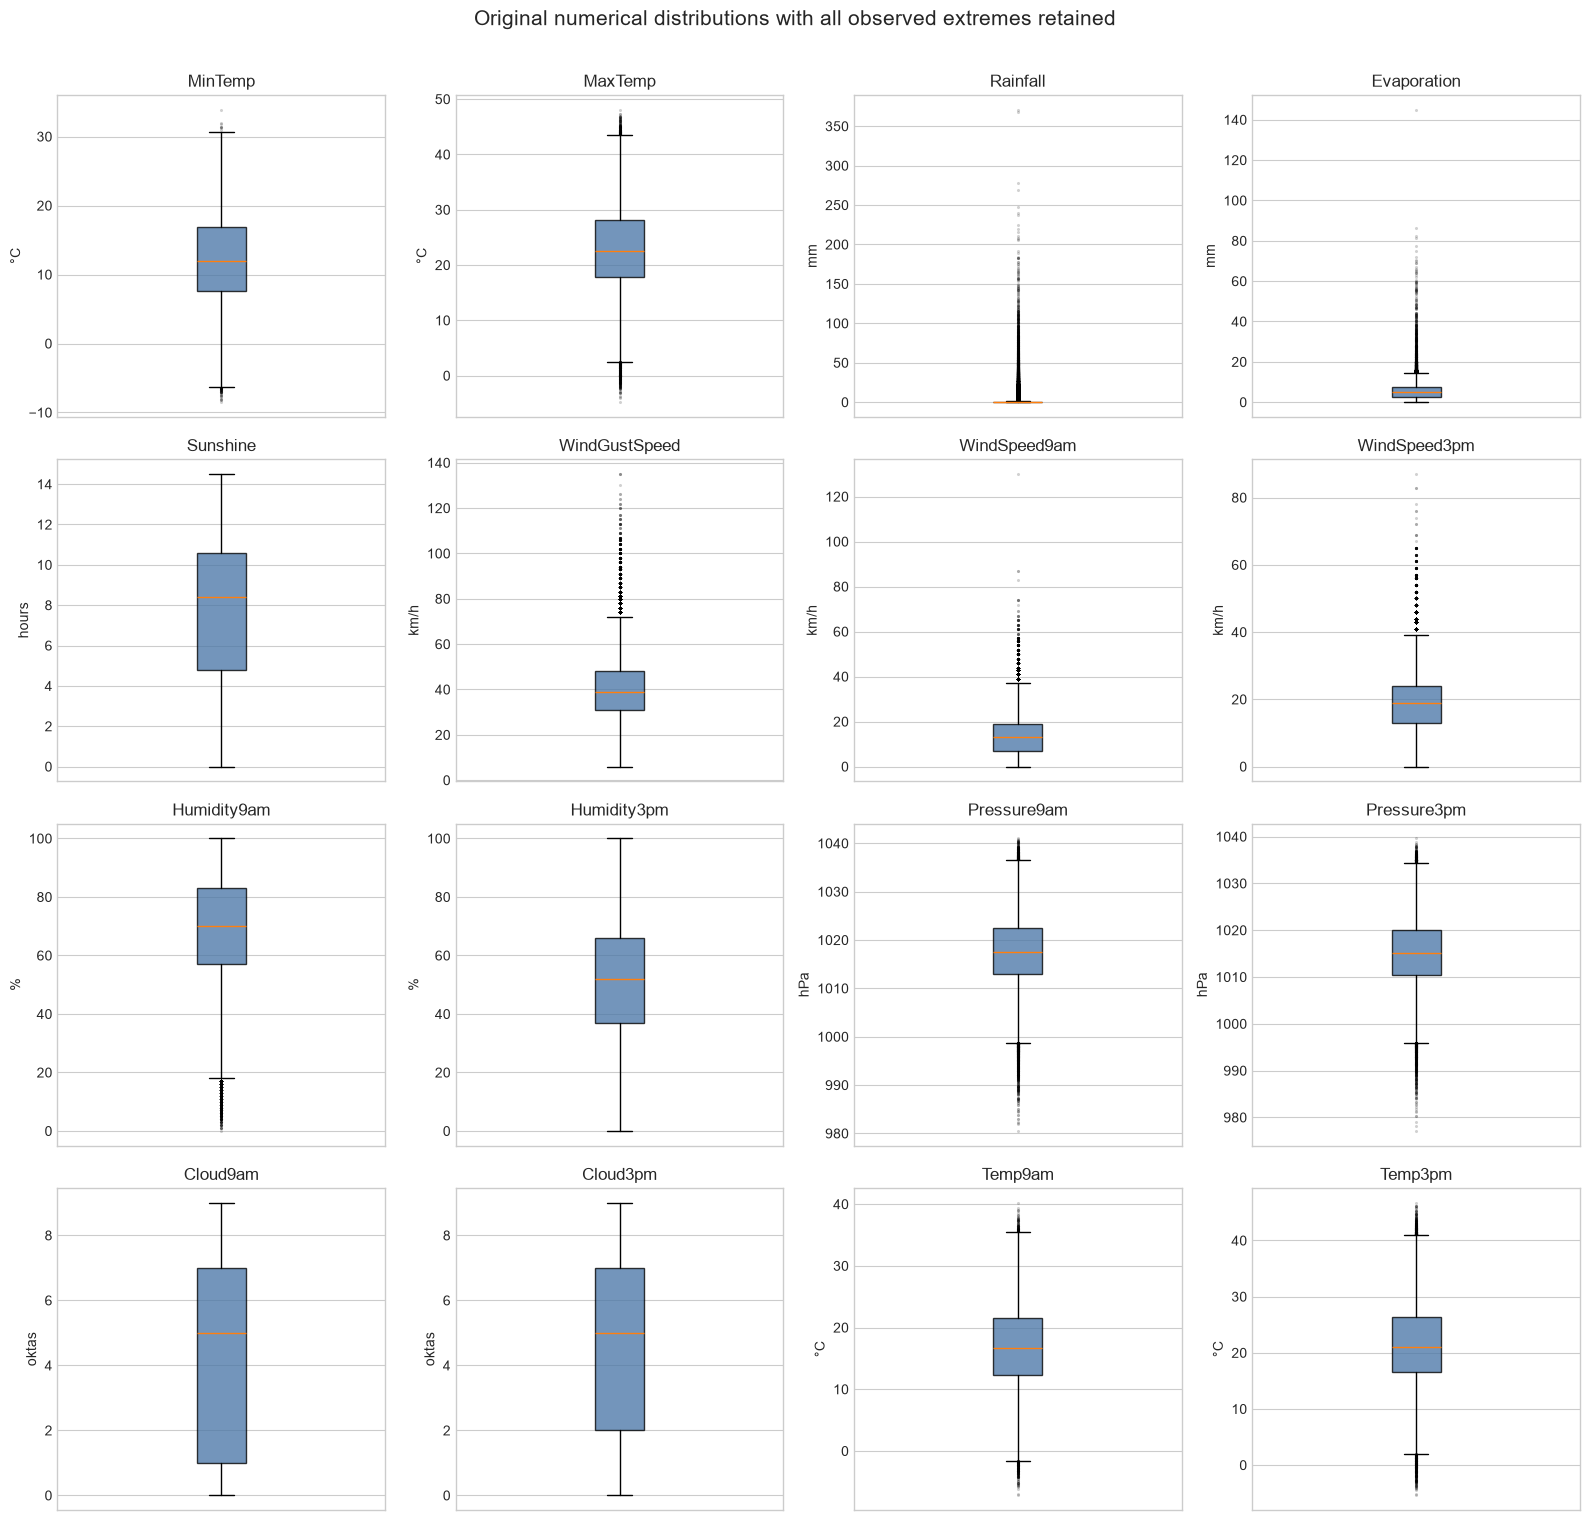

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 15))
for ax, feature in zip(axes.flat, NUMERICAL_FEATURES):
    values = weather[feature].dropna().to_numpy()
    box = ax.boxplot(values, vert=True, patch_artist=True, showfliers=True,
                     flierprops={"markersize": 1.2, "alpha": 0.18})
    box["boxes"][0].set_facecolor(PRIMARY)
    box["boxes"][0].set_alpha(0.78)
    ax.set_title(feature)
    ax.set_xticks([])
    ax.set_ylabel(UNITS[feature])
fig.suptitle("Original numerical distributions with all observed extremes retained", y=1.01, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_numeric_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

## 2. Rainfall skewness and upper tail

Rainfall contains a large zero mass and a long positive tail. This structure makes the symmetric IQR rule flag many genuinely wet observations. No log transform or other transformation is applied.

,Rainfall metric,Value,Context
0,Non-missing Rainfall count,142199.000000,rows
1,Zero-rain count,91080.000000,rows
2,Zero-rain percentage,64.051100,percentage of non-missing
3,Positive-rain count,51119.000000,rows
4,All-value skewness,9.836225,sample skewness
5,Positive-only skewness,6.387431,sample skewness
6,99th percentile,37.400000,mm
7,99.9th percentile,102.000000,mm
8,Maximum,371.000000,mm
9,Count >= 100 mm,151.000000,rows


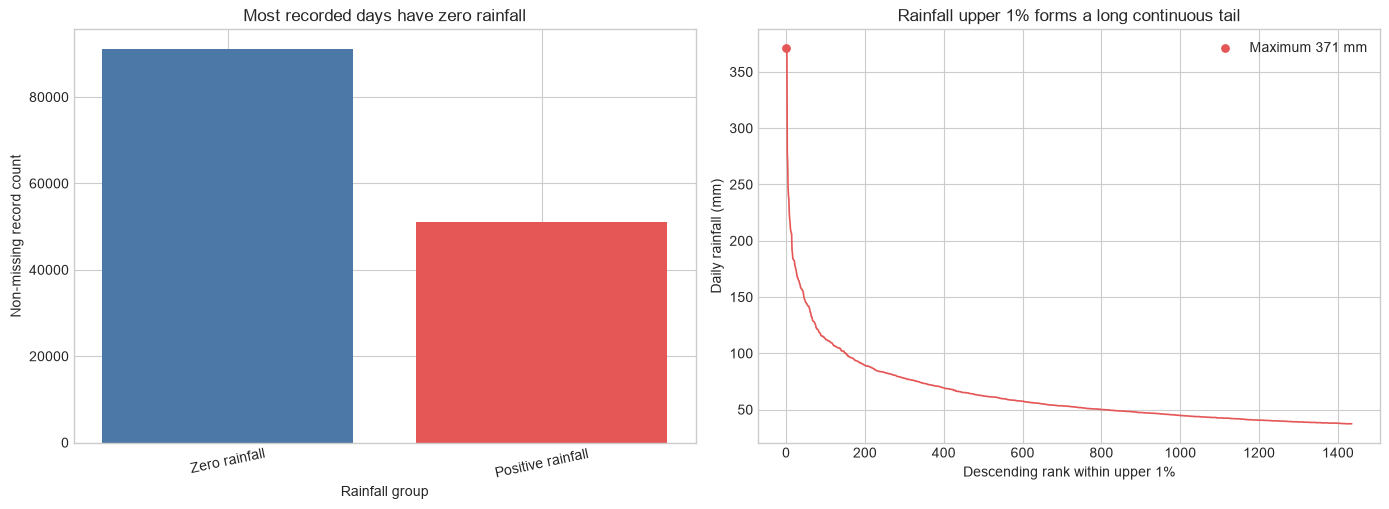

In [5]:
rainfall_summary = rainfall_skewness_summary(weather)
rainfall_summary.to_csv(TABLE_DIR / "05_rainfall_skewness.csv", index=False)
display(rainfall_summary)

rain = weather["Rainfall"].dropna()
zero_positive = pd.Series({"Zero rainfall": int(rain.eq(0).sum()), "Positive rainfall": int(rain.gt(0).sum())})
upper_tail = rain.loc[rain.ge(rain.quantile(0.99))].sort_values(ascending=False).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].bar(zero_positive.index, zero_positive.values, color=[PRIMARY, ACCENT])
axes[0].set_title("Most recorded days have zero rainfall")
axes[0].set_xlabel("Rainfall group")
axes[0].set_ylabel("Non-missing record count")
axes[0].tick_params(axis="x", rotation=12)

axes[1].plot(np.arange(1, len(upper_tail) + 1), upper_tail, color=ACCENT, linewidth=1.2)
axes[1].scatter([1], [upper_tail.iloc[0]], color=ACCENT, s=28, label=f"Maximum {upper_tail.iloc[0]:g} mm")
axes[1].set_title("Rainfall upper 1% forms a long continuous tail")
axes[1].set_xlabel("Descending rank within upper 1%")
axes[1].set_ylabel("Daily rainfall (mm)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_rainfall_distribution_tail.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Cloud value 9 and humidity boundaries

,Feature,Value,Date,Location,Year,Month,Other cloud value,Rainfall,Humidity9am,Humidity3pm,RainTomorrow,Pattern assessment
0,Cloud9am,9,2009-09-23,Sydney,2009,9,3.0,4.4,40.0,36.0,No,Sporadic: isolated across different locations/dates in the observed data.
1,Cloud9am,9,2012-05-27,Canberra,2012,5,NaN,0.0,99.0,41.0,No,Sporadic: isolated across different locations/dates in the observed data.
2,Cloud3pm,9,2012-11-02,Woomera,2012,11,6.0,0.2,45.0,13.0,No,Sporadic: isolated across different locations/dates in the observed data.


,Feature,Non-missing count,Minimum,Maximum,Count below 0,Count equal to 0,Count equal to 100,Count above 100,Outside 0–100 range,Assessment
0,Humidity9am,142806,0.0,100.0,0,1,2863,0,0,Within the physical 0–100% bounds; boundary values retained for review.
1,Humidity3pm,140953,0.0,100.0,0,4,400,0,0,Within the physical 0–100% bounds; boundary values retained for review.


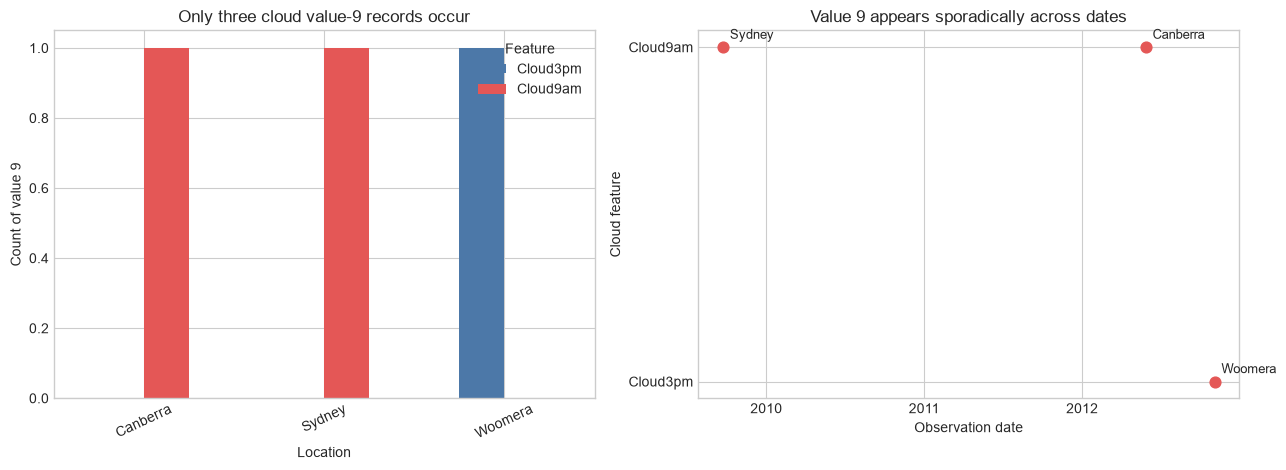

Cloud 9 is outside the documented 0–8 okta scale, but possible special coding is unresolved; nothing is recoded.
Humidity has no values outside 0–100%. Rare 0% and repeated 100% boundaries are retained for review.


In [6]:
cloud_nines = cloud_nine_investigation(weather)
humidity_boundaries = humidity_boundary_summary(weather)
cloud_nines.to_csv(TABLE_DIR / "05_cloud9_investigation.csv", index=False)
humidity_boundaries.to_csv(TABLE_DIR / "05_humidity_boundary_summary.csv", index=False)
display(cloud_nines)
display(humidity_boundaries)

location_counts = cloud_nines.groupby(["Location", "Feature"]).size().unstack(fill_value=0)
cloud_dates = pd.to_datetime(cloud_nines["Date"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
location_counts.plot(kind="bar", ax=axes[0], color=[PRIMARY, ACCENT])
axes[0].set_title("Only three cloud value-9 records occur")
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Count of value 9")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Feature")

feature_y = cloud_nines["Feature"].map({"Cloud9am": 1, "Cloud3pm": 0})
axes[1].scatter(cloud_dates, feature_y, color=ACCENT, s=60)
for date, y, location in zip(cloud_dates, feature_y, cloud_nines["Location"]):
    axes[1].annotate(location, (date, y), xytext=(5, 6), textcoords="offset points", fontsize=9)
axes[1].set_yticks([0, 1], ["Cloud3pm", "Cloud9am"])
axes[1].set_title("Value 9 appears sporadically across dates")
axes[1].set_xlabel("Observation date")
axes[1].set_ylabel("Cloud feature")
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_cloud9_occurrences.png", dpi=180, bbox_inches="tight")
plt.show()

print("Cloud 9 is outside the documented 0–8 okta scale, but possible special coding is unresolved; nothing is recoded.")
print("Humidity has no values outside 0–100%. Rare 0% and repeated 100% boundaries are retained for review.")

## 4. Evaporation and wind upper-tail patterns

,Feature,99th-percentile threshold,Count at/above threshold,Locations represented,Years represented,First date,Last date,Observed maximum,Maximum occurrence count,Co-occurring positive Rainfall count,RainTomorrow Yes rate among labelled extremes,Pattern assessment
0,Evaporation,18.4,841,26,10,2008-10-13,2017-04-24,145.0,1,191,11.8501,Upper tail repeats across multiple stations/years
1,WindGustSpeed,81.0,1368,47,11,2007-11-03,2017-06-20,135.0,3,711,57.7761,Upper tail repeats across multiple stations/years
2,WindSpeed9am,39.0,1817,42,11,2007-12-22,2017-06-13,130.0,1,845,40.9431,Upper tail repeats across multiple stations/years
3,WindSpeed3pm,43.0,1867,45,11,2007-12-27,2017-06-19,87.0,1,871,44.0044,Upper tail repeats across multiple stations/years


,Selected feature,Selected rule,Selected value,Date,Location,Rainfall,Evaporation,WindGustSpeed,WindSpeed9am,WindSpeed3pm,MaxTemp,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,RainToday,RainTomorrow
0,Rainfall,Rainfall maximum = 371 mm,371.0,2009-11-07,CoffsHarbour,371.0,NaN,NaN,13.0,19.0,23.1,93.0,81.0,1026.6,1025.9,Yes,Yes
1,Evaporation,Evaporation maximum = 145 mm,145.0,2016-12-19,Williamtown,58.2,145.0,NaN,NaN,30.0,23.9,72.0,52.0,1020.8,1017.0,Yes,No
2,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2015-04-21,NorahHead,61.4,NaN,135.0,87.0,74.0,19.7,93.0,96.0,1014.9,1013.2,Yes,Yes
3,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2011-02-03,Townsville,NaN,NaN,135.0,65.0,41.0,28.6,83.0,89.0,1004.0,1006.0,NaN,Yes
4,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2010-12-07,Woomera,2.6,7.2,135.0,31.0,NaN,37.8,68.0,NaN,1001.3,NaN,Yes,Yes
5,WindSpeed9am,WindSpeed9am maximum = 130 km/h,130.0,2017-01-18,Newcastle,0.0,NaN,NaN,130.0,NaN,41.0,35.0,NaN,NaN,NaN,No,No


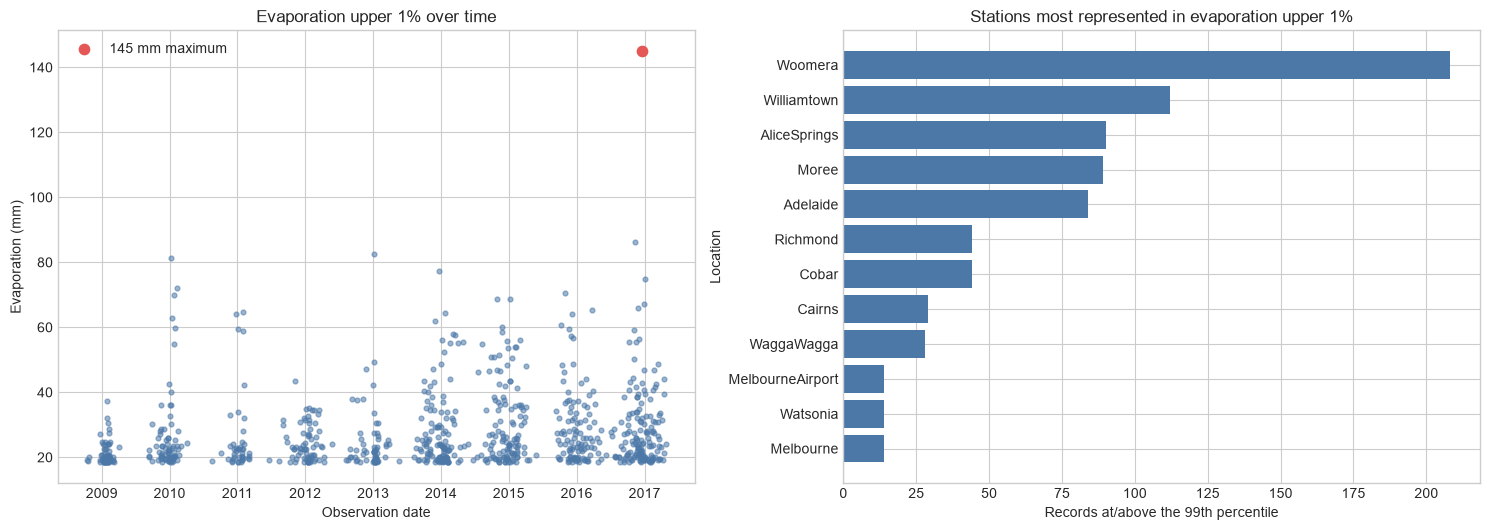

In [7]:
patterns = extreme_pattern_summary(weather)
specific_context = extreme_weather_context(weather)
patterns.to_csv(TABLE_DIR / "05_extreme_pattern_summary.csv", index=False)
specific_context.to_csv(TABLE_DIR / "05_extreme_weather_context.csv", index=False)
display(patterns)
display(specific_context)

evap_threshold = weather["Evaporation"].quantile(0.99)
evap_tail = weather.loc[weather["Evaporation"].ge(evap_threshold), ["Date", "Location", "Evaporation"]].copy()
evap_tail["Parsed date"] = pd.to_datetime(evap_tail["Date"])
evap_stations = evap_tail["Location"].value_counts().head(12).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
axes[0].scatter(evap_tail["Parsed date"], evap_tail["Evaporation"], s=12, alpha=0.55, color=PRIMARY)
max_evap = specific_context.loc[specific_context["Selected feature"] == "Evaporation"].iloc[0]
axes[0].scatter(pd.to_datetime(max_evap["Date"]), max_evap["Evaporation"], s=55, color=ACCENT, label="145 mm maximum")
axes[0].set_title("Evaporation upper 1% over time")
axes[0].set_xlabel("Observation date")
axes[0].set_ylabel("Evaporation (mm)")
axes[0].legend()
axes[1].barh(evap_stations.index, evap_stations.values, color=PRIMARY)
axes[1].set_title("Stations most represented in evaporation upper 1%")
axes[1].set_xlabel("Records at/above the 99th percentile")
axes[1].set_ylabel("Location")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_evaporation_extremes.png", dpi=180, bbox_inches="tight")
plt.show()

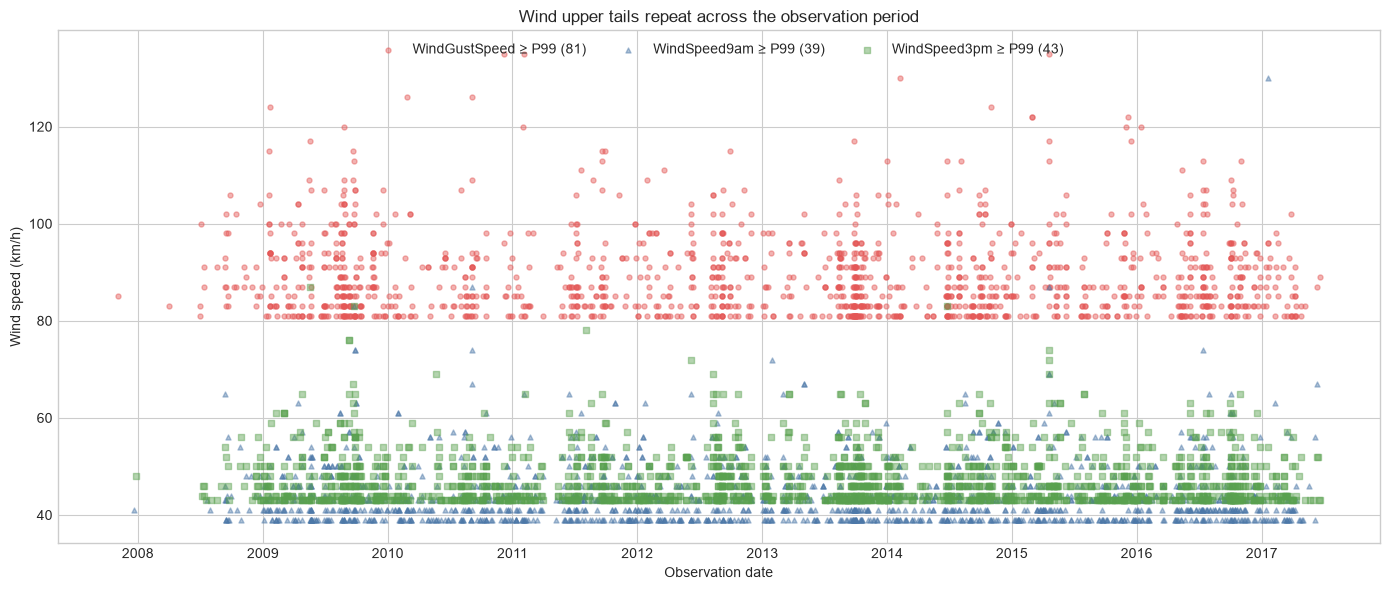

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
markers = {"WindGustSpeed": "o", "WindSpeed9am": "^", "WindSpeed3pm": "s"}
colors = {"WindGustSpeed": ACCENT, "WindSpeed9am": PRIMARY, "WindSpeed3pm": "#59A14F"}
for feature in ("WindGustSpeed", "WindSpeed9am", "WindSpeed3pm"):
    threshold = weather[feature].quantile(0.99)
    tail = weather.loc[weather[feature].ge(threshold), ["Date", feature]].copy()
    ax.scatter(pd.to_datetime(tail["Date"]), tail[feature], s=13, alpha=0.45,
               marker=markers[feature], color=colors[feature], label=f"{feature} ≥ P99 ({threshold:g})")
ax.set_title("Wind upper tails repeat across the observation period")
ax.set_xlabel("Observation date")
ax.set_ylabel("Wind speed (km/h)")
ax.legend(ncol=3, loc="upper center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_wind_extremes.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Specific suspicious/extreme rows and target context

The target context is descriptive only. A Yes or No target does not prove that an extreme measurement is valid or invalid and is not used to justify deletion.

In [9]:
suspicious_details = suspicious_value_details(weather)
suspicious_details.to_csv(TABLE_DIR / "05_suspicious_values.csv", index=False)
display(suspicious_details)

target_context = (
    suspicious_details.groupby(["Feature", "Trigger"], dropna=False)["RainTomorrow"]
    .agg(
        Selected_record_count="size",
        Labelled_target_count=lambda values: int(values.notna().sum()),
        Yes_count=lambda values: int(values.eq("Yes").sum()),
        No_count=lambda values: int(values.eq("No").sum()),
    )
    .reset_index()
)
target_context["Yes percentage among labelled"] = (
    target_context["Yes_count"] / target_context["Labelled_target_count"].replace(0, np.nan) * 100
).round(4)
target_context.to_csv(TABLE_DIR / "05_extreme_target_context.csv", index=False)
display(target_context)

,Feature,Trigger,Value,Date,Location,Rainfall,Evaporation,WindGustSpeed,WindSpeed9am,WindSpeed3pm,MaxTemp,Humidity9am,Humidity3pm,RainToday,RainTomorrow,Classification
0,Cloud9am,Cloud9am = 9,9.0,2009-09-23,Sydney,4.4,11.2,NaN,30.0,37.0,21.8,40.0,36.0,Yes,No,suspicious / investigate later
1,Rainfall,Rainfall maximum = 371 mm,371.0,2009-11-07,CoffsHarbour,371.0,NaN,NaN,13.0,19.0,23.1,93.0,81.0,Yes,Yes,likely valid extreme
2,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2010-12-07,Woomera,2.6,7.2,135.0,31.0,NaN,37.8,68.0,NaN,Yes,Yes,likely valid extreme
3,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2011-02-03,Townsville,NaN,NaN,135.0,65.0,41.0,28.6,83.0,89.0,NaN,Yes,likely valid extreme
4,Cloud9am,Cloud9am = 9,9.0,2012-05-27,Canberra,0.0,NaN,30.0,4.0,9.0,14.5,99.0,41.0,No,No,suspicious / investigate later
5,Cloud3pm,Cloud3pm = 9,9.0,2012-11-02,Woomera,0.2,11.6,39.0,26.0,17.0,24.6,45.0,13.0,No,No,suspicious / investigate later
6,Humidity3pm,Humidity3pm = 0%,0.0,2013-10-20,Woomera,0.0,19.0,61.0,28.0,33.0,40.0,0.0,0.0,No,No,unresolved
7,Humidity9am,Humidity9am = 0%,0.0,2013-10-20,Woomera,0.0,19.0,61.0,28.0,33.0,40.0,0.0,0.0,No,No,unresolved
8,Humidity3pm,Humidity3pm = 0%,0.0,2014-11-13,Woomera,0.0,12.0,69.0,20.0,24.0,41.6,2.0,0.0,No,No,unresolved
9,WindGustSpeed,WindGustSpeed maximum = 135 km/h,135.0,2015-04-21,NorahHead,61.4,NaN,135.0,87.0,74.0,19.7,93.0,96.0,Yes,Yes,likely valid extreme


,Feature,Trigger,Selected_record_count,Labelled_target_count,Yes_count,No_count,Yes percentage among labelled
0,Cloud3pm,Cloud3pm = 9,1,1,0,1,0.0
1,Cloud9am,Cloud9am = 9,2,2,0,2,0.0
2,Evaporation,Evaporation maximum = 145 mm,1,1,0,1,0.0
3,Humidity3pm,Humidity3pm = 0%,4,4,0,4,0.0
4,Humidity9am,Humidity9am = 0%,1,1,0,1,0.0
5,Rainfall,Rainfall maximum = 371 mm,1,1,1,0,100.0
6,WindGustSpeed,WindGustSpeed maximum = 135 km/h,3,3,3,0,100.0
7,WindSpeed9am,WindSpeed9am maximum = 130 km/h,1,1,0,1,0.0


## 6. Final classification and future handling options

In [10]:
decisions = outlier_decision_summary(weather)
decisions.to_csv(TABLE_DIR / "05_outlier_decision_summary.csv", index=False)
display(decisions)

print("No observed value is classified as likely invalid because the available evidence does not establish a clear domain error.")
print("Future options—retention, robust scaling, transformation, capping, or conversion to missing—remain proposals only.")

,Feature,Observed unusual value / rule,Number affected,Percentage affected,Statistical outlier?,Domain-plausible?,Classification,Recommended future handling,Reason
0,MinTemp,Observed endpoints -8.5 to 33.9 °C,2,0.001375,Yes; one or both endpoints cross an IQR fence,Plausible for Australian weather observations,likely valid extreme,Retain unchanged; consider robust scaling later if needed.,Extreme temperatures remain within credible terrestrial weather ranges.
1,MaxTemp,Observed endpoints -4.8 to 48.1 °C,2,0.001375,Yes; one or both endpoints cross an IQR fence,Plausible for Australian weather observations,likely valid extreme,Retain unchanged; consider robust scaling later if needed.,Extreme temperatures remain within credible terrestrial weather ranges.
2,Temp9am,Observed endpoints -7.2 to 40.2 °C,2,0.001375,Yes; one or both endpoints cross an IQR fence,Plausible for Australian weather observations,likely valid extreme,Retain unchanged; consider robust scaling later if needed.,Extreme temperatures remain within credible terrestrial weather ranges.
3,Temp3pm,Observed endpoints -5.4 to 46.7 °C,2,0.001375,Yes; one or both endpoints cross an IQR fence,Plausible for Australian weather observations,likely valid extreme,Retain unchanged; consider robust scaling later if needed.,Extreme temperatures remain within credible terrestrial weather ranges.
4,Humidity9am,Humidity = 0%,1,0.000687,Yes for Humidity9am; no for Humidity3pm under IQR screening,At the physical boundary; measurement context uncertain,unresolved,Retain for now; investigate station/date context before any later rule.,"No values violate 0–100%, but exact zero is rare and location-concentrated."
5,Humidity9am,Humidity = 100%,2863,1.968239,May be IQR-flagged depending on feature distribution,Yes; saturation is physically possible,likely valid extreme,Retain unchanged.,The value is within the credible humidity constraint and occurs repeatedly.
6,Humidity3pm,Humidity = 0%,4,0.002750,Yes for Humidity9am; no for Humidity3pm under IQR screening,At the physical boundary; measurement context uncertain,unresolved,Retain for now; investigate station/date context before any later rule.,"No values violate 0–100%, but exact zero is rare and location-concentrated."
7,Humidity3pm,Humidity = 100%,400,0.274990,May be IQR-flagged depending on feature distribution,Yes; saturation is physically possible,likely valid extreme,Retain unchanged.,The value is within the credible humidity constraint and occurs repeatedly.
8,Pressure9am,Observed endpoints 980.5 to 1041 hPa,2,0.001375,Yes; endpoints cross IQR fences,Plausible synoptic pressure range; no project-backed violation identified,likely valid extreme,Retain unchanged; use robust scaling later if warranted.,Low/high values are unusual but not clearly physically implausible.
9,Pressure3pm,Observed endpoints 977.1 to 1039.6 hPa,2,0.001375,Yes; endpoints cross IQR fences,Plausible synoptic pressure range; no project-backed violation identified,likely valid extreme,Retain unchanged; use robust scaling later if warranted.,Low/high values are unusual but not clearly physically implausible.


No observed value is classified as likely invalid because the available evidence does not establish a clear domain error.
Future options—retention, robust scaling, transformation, capping, or conversion to missing—remain proposals only.


## 7. Proposal consistency

In [11]:
proposal = proposal_consistency(weather)
proposal.to_csv(TABLE_DIR / "05_proposal_consistency.csv", index=False)
display(proposal)

,Claim,Expected,Actual,Match / Mismatch,Comment
0,Rainfall is strongly skewed and has many IQR-flagged observations,Strong right skew and substantial IQR flags,Skewness 9.836225; 17.9875% IQR-flagged,Match,The zero mass and long positive tail naturally make IQR screening flag many wet days.
1,Maximum Rainfall is 371 mm,371 mm,371 mm,Match,One observed record; retained for contextual review.
2,Evaporation and wind contain some extreme values,Extreme upper-tail values present,Evaporation max 145 mm; gust max 135 km/h; 9am wind max 130 km/h,Match,Upper tails were quantified without changing values.
3,Extremes may be genuine weather events rather than errors,Do not equate statistical outliers with errors,Rainfall and gust maxima have supporting weather context; evaporation 145 and 9am wind 130 remain suspicious,Match,"The dataset supports mixed, cautious classifications rather than blanket deletion."
4,Humidity lies within 0–100%,No values below 0 or above 100,0 values outside 0–100%,Match,Rare 0% boundary values remain unresolved but are not outside the range.
5,Cloud data include value 9 despite a documented 0–8 scale,At least one cloud value 9,3 rows across Cloud9am/Cloud3pm,Match,Three sporadic records require source-code clarification; none were recoded.


## 8. Conclusions and unresolved questions

**Observation:** IQR screening flags 17.9875% of non-missing Rainfall values, far more than any other feature, because the distribution contains many zeros and a long positive tail.

**Interpretation:** rainfall and wind-gust extremes can be unusual yet credible weather events. The isolated 145 mm evaporation and 130 km/h 9am wind records have weaker supporting context and remain suspicious. Cloud value 9 conflicts with the documented 0–8 scale but may be a source-specific code. Rare 0% humidity values remain within the physical boundary but are concentrated at Woomera.

**Future consideration:** later stages may compare robust scaling, rainfall transformation, or evidence-backed handling of suspicious source codes. No such option is implemented here. External station/source metadata is still required to resolve cloud 9, evaporation 145 mm, WindSpeed9am 130 km/h, and rare 0% humidity readings.

In [12]:
expected_tables = [
    "05_percentile_summary.csv", "05_outlier_summary.csv", "05_cloud9_investigation.csv",
    "05_humidity_boundary_summary.csv", "05_rainfall_skewness.csv", "05_extreme_pattern_summary.csv",
    "05_extreme_weather_context.csv", "05_suspicious_values.csv", "05_extreme_target_context.csv",
    "05_outlier_decision_summary.csv", "05_proposal_consistency.csv",
]
expected_figures = [
    "05_iqr_flagged_percentages.png", "05_numeric_boxplots.png", "05_rainfall_distribution_tail.png",
    "05_cloud9_occurrences.png", "05_evaporation_extremes.png", "05_wind_extremes.png",
]
assert weather.shape == raw_shape == (145_460, 23)
assert all((TABLE_DIR / name).is_file() for name in expected_tables)
assert all((FIGURE_DIR / name).is_file() for name in expected_figures)
assert set(decisions["Classification"]).issubset(ALLOWED_CLASSIFICATIONS)
assert int(humidity_boundaries["Outside 0–100 range"].sum()) == 0
assert len(cloud_nines) == 3
print(f"T05 notebook checks complete: {len(expected_tables)} tables and {len(expected_figures)} figures exist.")
print("No raw values were modified or removed, and T06 was not started.")

T05 notebook checks complete: 11 tables and 6 figures exist.
No raw values were modified or removed, and T06 was not started.
